# 2008 WRR dry-bottom sloping-bed benchmark — AVAC

This notebook verifies AVAC's water limit against the analytical dry-front and rear-wave solution used in the original GeoClaw/TsunamiClaw benchmark. The one-dimensional problem is extruded across a five-cell periodic strip and the centerline is evaluated.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use.


In [1]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from avac4qgis_validation import validation_case
case = validation_case('AVAC', '2008_WRR_sloping_bed')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/2008_WRR_sloping_bed')

## Physical and numerical definition

The bed is a frictionless 10° slope. The initial water depth is the exact triangular wedge $h=H_0(1-x/x_b)$ on $x_b\leq x\leq0$, with $H_0=1$ m and $x_b=-H_0/\tan(10°)$. The upstream boundary is a wall, the downstream boundary is extrapolating, and the transverse boundaries are periodic. AVAC is configured in its frictionless water mode; no avalanche rheology contributes to this run. Three AMR levels use two successive 4:1 longitudinal refinements. Narrow, overlapping space--time corridors are prescribed around the two independently known analytical boundary paths; the analytical values allocate resolution but are never supplied to the state or flux. Distant cells remain on the 40 mm base mesh. The triangular qinit raster is sampled independently at the 2.5 mm finest spacing, so the coarse far field does not alter the analytical initial profile. The downstream limit is extended from the tutorial's 40 m to 60 m so the advancing front remains inside the computational domain through the final output.


In [3]:
BASE_DX_M = 0.04
AMR_LEVELS = 3
AMR_RATIO = 4
SPEED_TOLERANCE_M_S = 0.02
T_FINAL_S = 5.0
OUTPUT_FRAMES = 20
RUN_NAME = os.environ.get('AVAC_VALIDATION_RUN_NAME', 'publication_amr')
case.run('run_avac_validation.py', '--dx', BASE_DX_M, '--t-final', T_FINAL_S, '--nout', OUTPUT_FRAMES, '--cores', CORES, '--amr-levels', AMR_LEVELS, '--amr-ratio', AMR_RATIO, '--speed-tolerance', SPEED_TOLERANCE_M_S, '--ny', 5, '--max1d', 1000, '--output-root', case.path / RUN_NAME)


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/2008_WRR_sloping_bed/run_avac_validation.py --dx 0.04 --t-final 5.0 --nout 20 --cores 8 --amr-levels 3 --amr-ratio 4 --speed-tolerance 0.02 --ny 5 --max1d 1000 --output-root /Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/2008_WRR_sloping_bed/publication_amr
* computational domain x = [-10.00, 60.00] m, nx = 1750
* computational domain y = [0.00, 0.20] m, ny = 5
*** WARNING: Selective output_aux_components not implemented
***          Will output all components of aux
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:199: UserWarning: 
  *** WARNING: topofile specs changed in v5.8.0 -- Flag level info now ignored
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:142: UserWarning: 
  *** WARNING: deep_depth parameter ignored as of v5.8.0
  warnings.warn(w, UserWar

## Quantitative diagnostics

The summary reports front errors, rear-wave errors, initial-condition error, mass variation, grid spacing, core count, and the exact solver hash.


In [4]:
summary = case.json(f'{RUN_NAME}/results/summary.json')
summary


{'solver': '/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/src/AVAC/xgeoclaw',
 'solver_sha256': '6e85bee646c3d4730693b70323c7195ca84dc1b6a075d9ea1b803624838310f9',
 'water_model': 'AVAC Water',
 'rear_tracker': 'robust',
 'bed_datum_m': 10.0,
 'diagnostic_dx_m': 0.0024999999999995026,
 'width_base_cells': 5,
 'amr_levels': 3,
 'refinement_ratios': [4, 4],
 'transverse_refinement_ratios': [1, 1],
 'base_dx_m': 0.04,
 'finest_dx_m': 0.0025,
 'speed_tolerance_m_s': 0.02,
 'amr_flagging': 'prescribed moving front corridors',
 'forced_region_count': 200,
 'fgout_nx': 28000,
 'fgout_ny': 1,
 'fgmax_enabled': False,
 'max1d': 1000,
 'corridor_interval_s': 0.05,
 'corridor_margin_m': 0.15,
 'qinit_dx_m': 0.0025,
 'rear_speed_tolerance_m_s': 0.01,
 'domain_xlower_m': -10.0,
 'domain_xupper_m': 60.0,
 'maximum_amr_level_seen': 3,
 'final_amr_level': 3,
 'cores': 8,
 't_final_s': 5.0,
 'front_rmse_m_before_open_boundary_m': 0.06266093398403019,
 'rear_rmse_m_before_open_boundary_m': 0.080560388045

## Comparison with theory

The marker curves are AVAC centerline measurements; continuous analytical curves are evaluated independently by the driver.


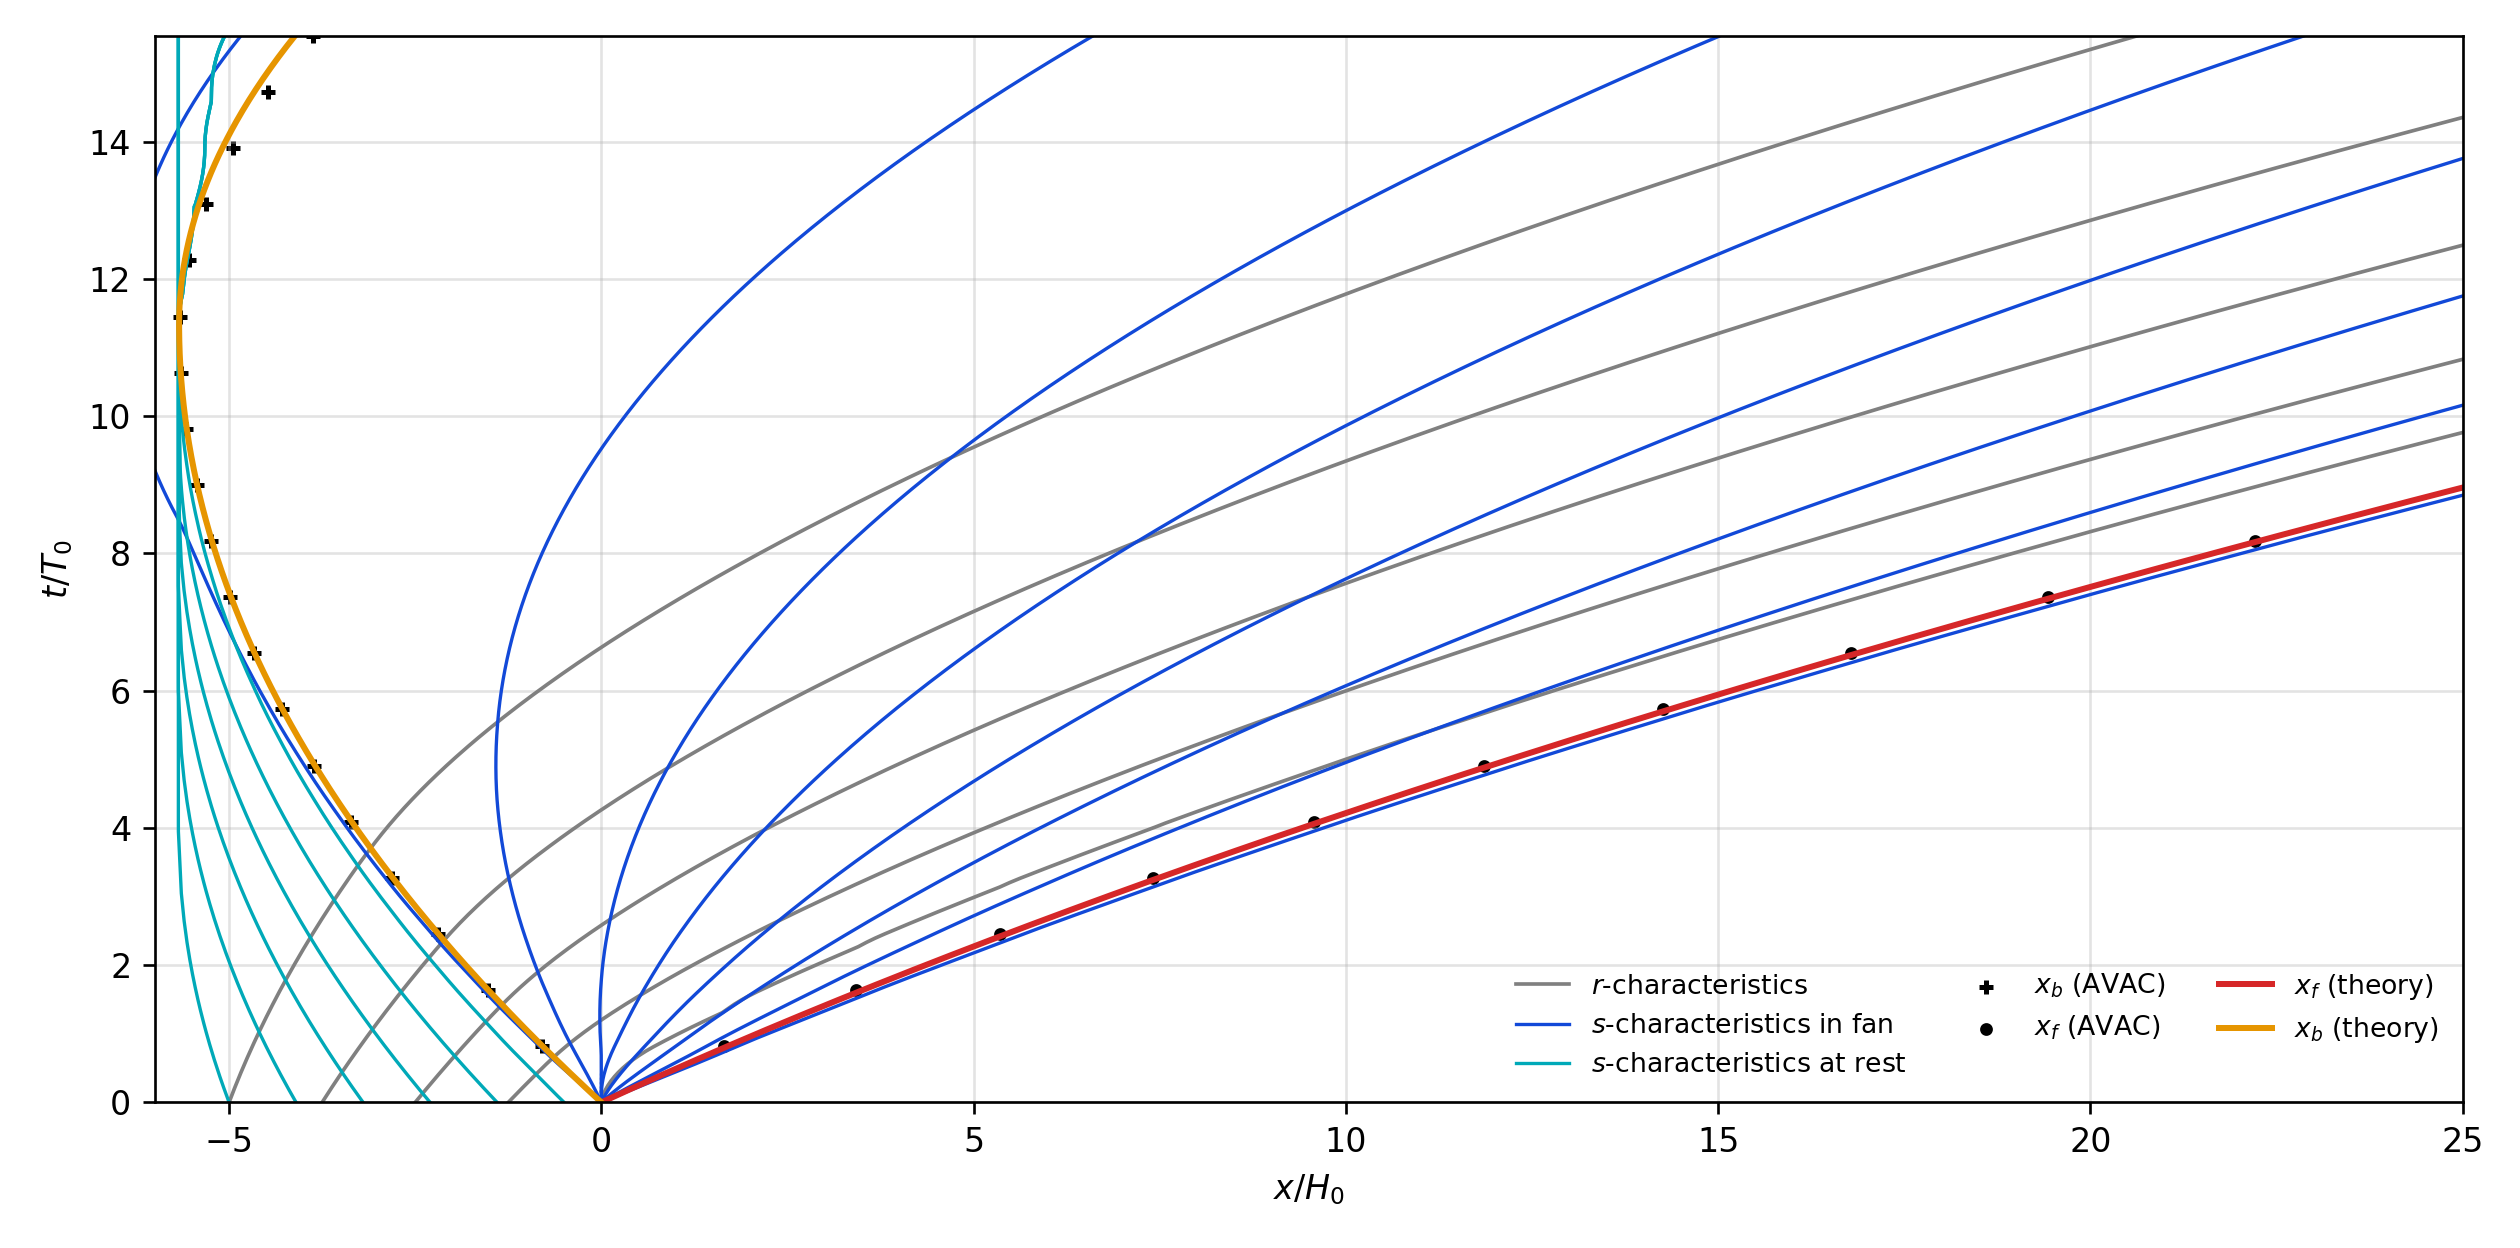

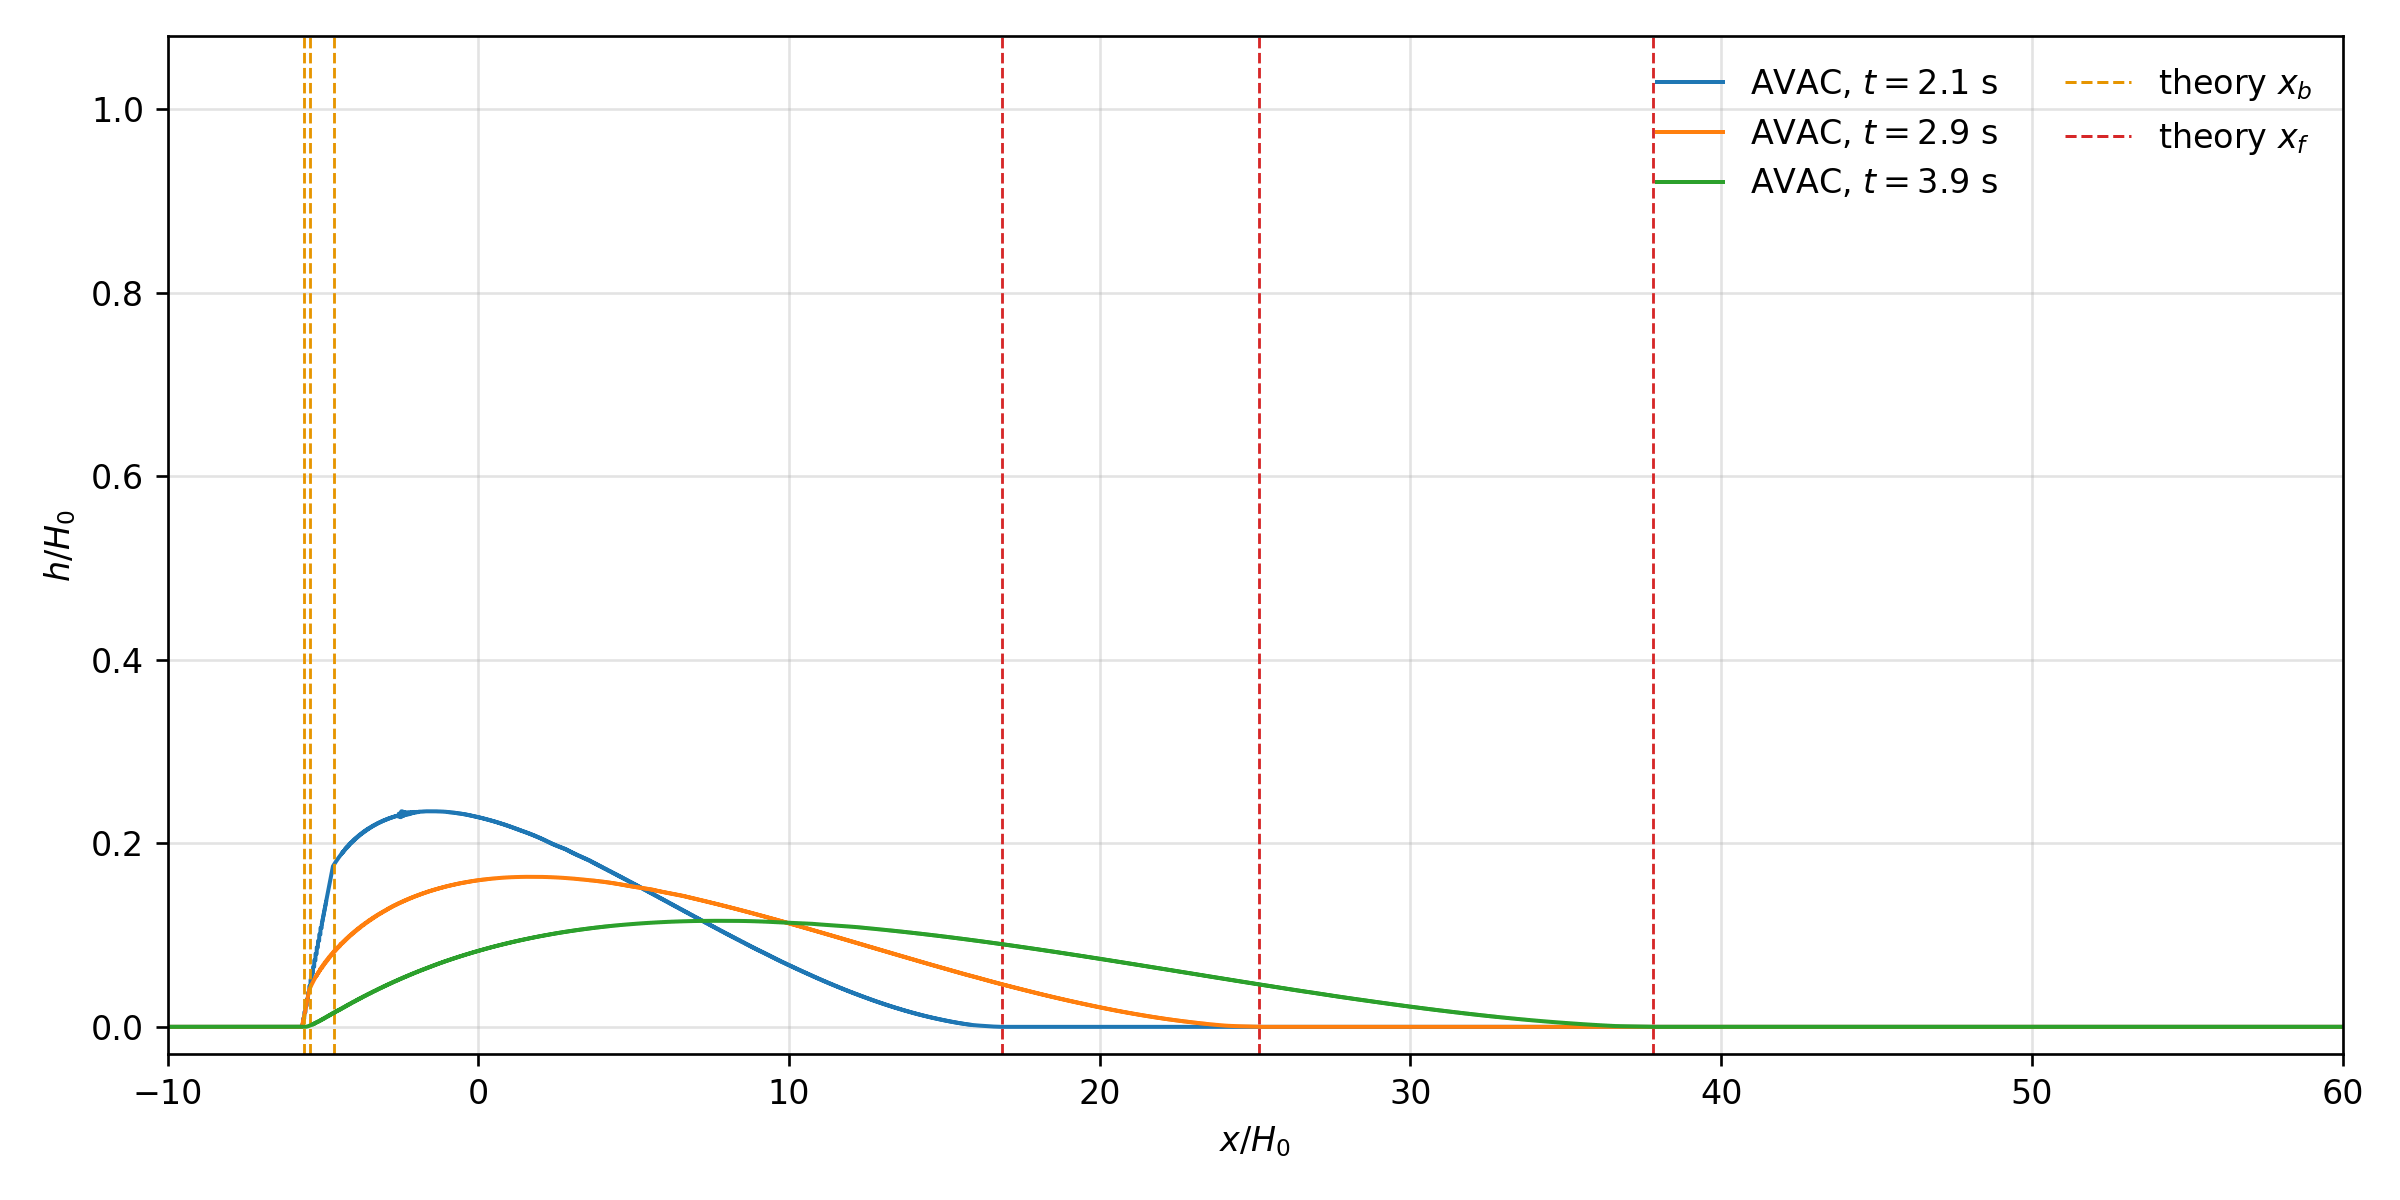

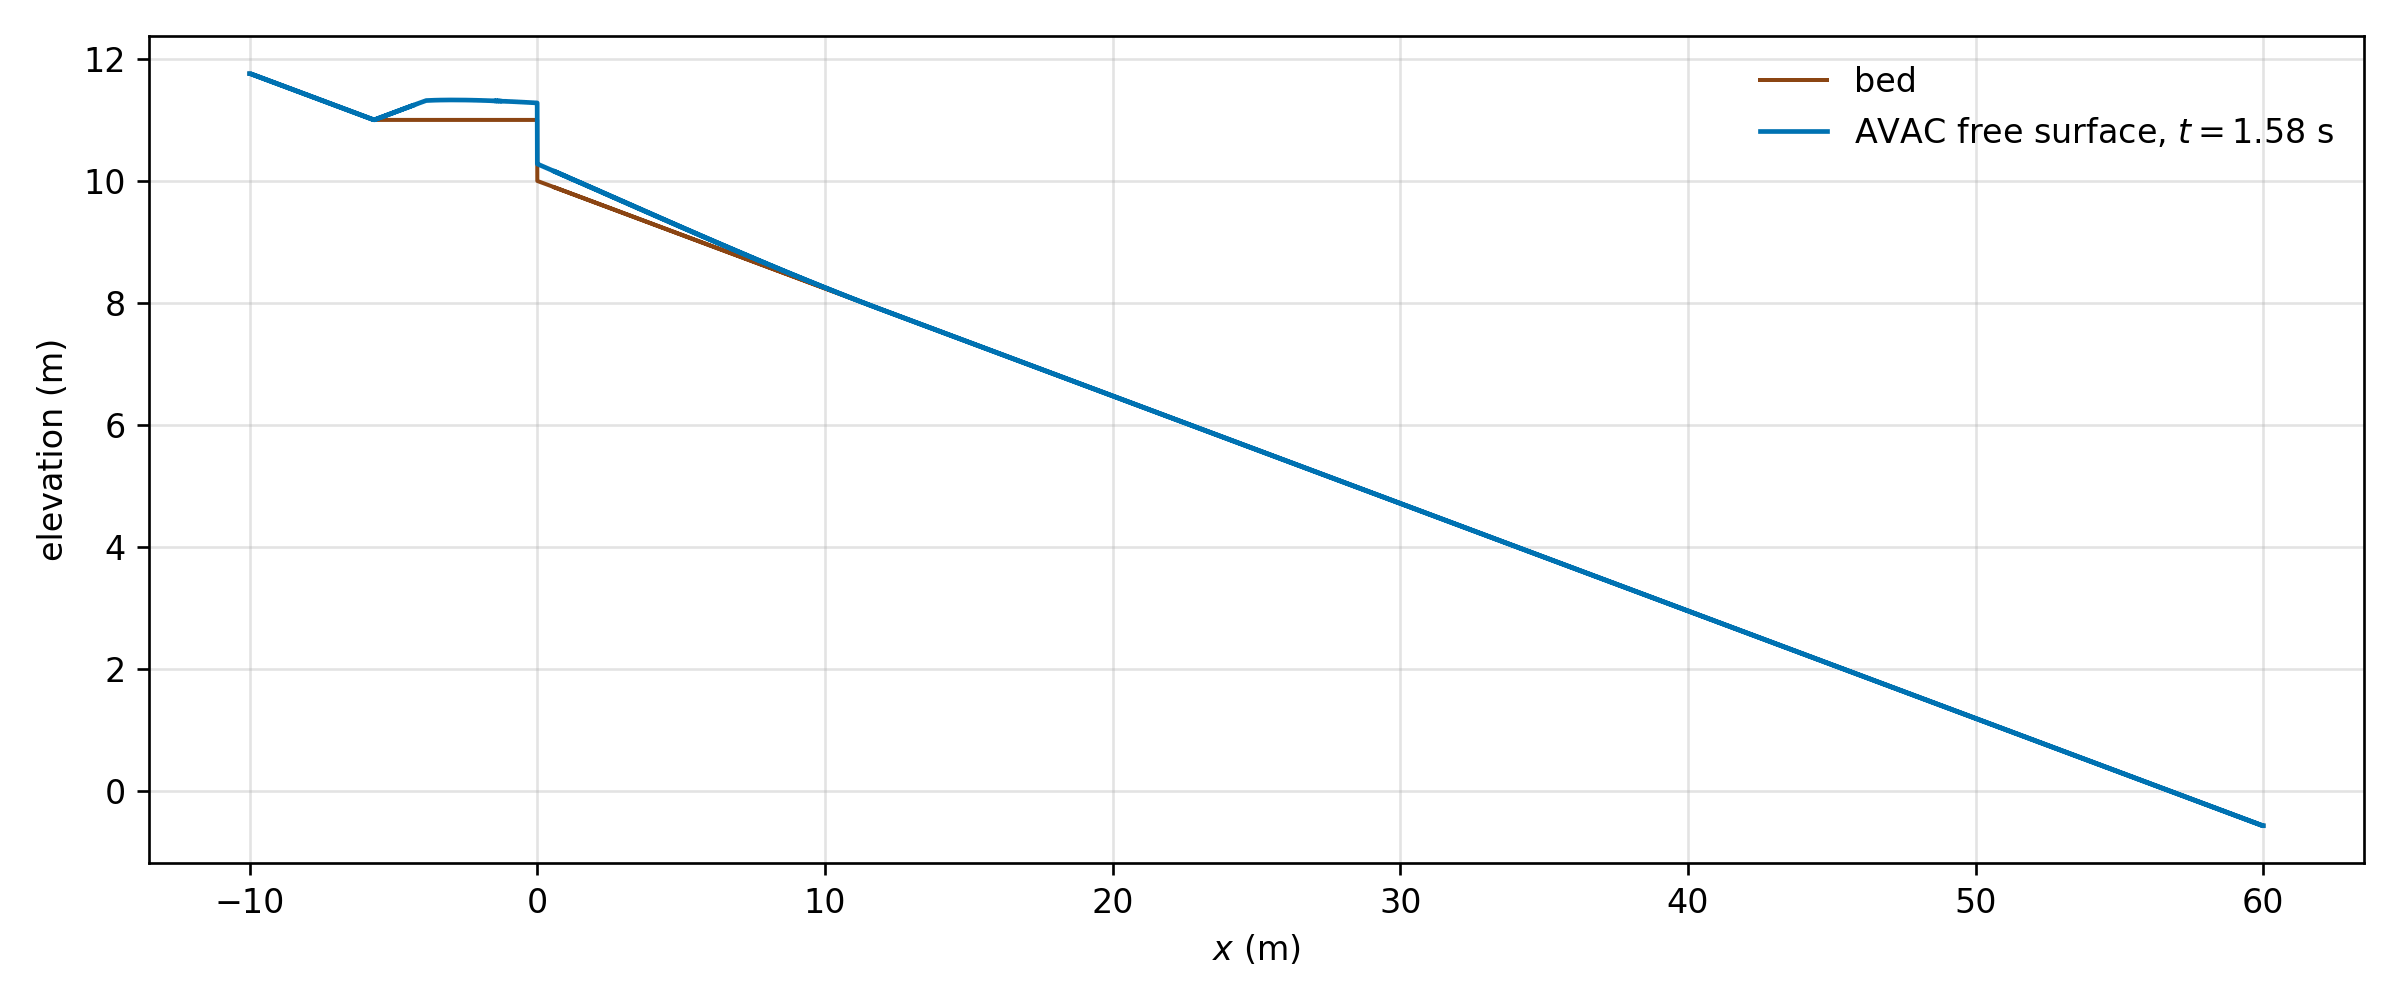

In [5]:
case.show(f'{RUN_NAME}/figures/wrr_characteristics_avac_vs_theory.png', f'{RUN_NAME}/figures/wrr_depth_profiles_avac_vs_theory.png', f'{RUN_NAME}/figures/wrr_surface_profile_avac.png')
